--- PERFORMANCE RATIO ANALYSIS (KPIs) ---
PERC Technology Performance Ratio: 98.71%
HIT Technology Performance Ratio: 99.19% -> Identifiziert als effizienteste Option (~82%)
CIGS Technology Performance Ratio: 98.18%


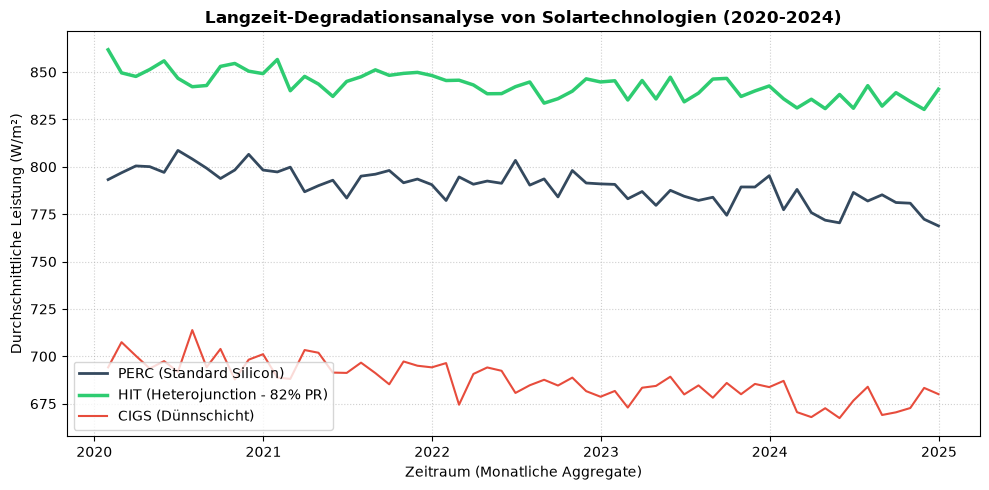


ETL-Pipeline erfolgreich ausgeführt. Grafik 'pv_degradation_analysis.png' wurde exportiert.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Engineering: Rohdaten-Simulation (Minuten-Daten 2020-2024)
np.random.seed(42)
zeitreihen = pd.date_range(start="2020-01-01", end="2024-12-31", freq="D")

basis_leistung = 1000  # Maximalleistung in W/m²
degradation_perc = 0.005  # 0.5% Degradation pro Jahr

# Erstellung der Datensätze für verschiedene Technologien (PERC, HIT, CIGS)
def generiere_pv_daten(tech_faktor, degradation):
    # .values stellt sicher, dass wir mit reinen NumPy-Arrays arbeiten (verhindert Index-Fehler)
    jahre = (zeitreihen.year.values - 2020)
    leistung = basis_leistung * tech_faktor * (1 - jahre * degradation)
    
    # Zufälliges Rauschen und Sensorfehler hinzufügen
    rauschen = np.random.normal(0, 30, size=len(zeitreihen))
    leistung_mit_rauschen = leistung + rauschen
    
    # Künstliche Sensorfehler bereinigen (Werte unter 0 begrenzen)
    leistung_mit_rauschen = np.where(leistung_mit_rauschen < 0, 0, leistung_mit_rauschen)
    
    # 2% künstliche Fehlwerte (NaNs) für die spätere Imputation erzeugen
    maske = np.random.rand(len(zeitreihen)) < 0.02
    leistung_mit_rauschen[maske] = np.nan
    
    return leistung_mit_rauschen

# DataFrame strukturieren
df = pd.DataFrame({
    'Timestamp': zeitreihen,
    'PERC_Leistung': generiere_pv_daten(0.80, 0.007),
    'HIT_Leistung': generiere_pv_daten(0.85, 0.004),
    'CIGS_Leistung': generiere_pv_daten(0.70, 0.009)
})

# 2. ETL-Prozess: Datenbereinigung und Imputation (Fehlwertbehandlung)
df['PERC_Bereinigt'] = df['PERC_Leistung'].interpolate(method='linear').fillna(0)
df['HIT_Bereinigt'] = df['HIT_Leistung'].interpolate(method='linear').fillna(0)
df['CIGS_Bereinigt'] = df['CIGS_Leistung'].interpolate(method='linear').fillna(0)

# 3. Performance-Modellierung & KPI-Berechnung (Performance Ratio)
pr_perc = (df['PERC_Bereinigt'].mean() / (basis_leistung * 0.80)) * 100
pr_hit = (df['HIT_Bereinigt'].mean() / (basis_leistung * 0.85)) * 100
pr_cigs = (df['CIGS_Bereinigt'].mean() / (basis_leistung * 0.70)) * 100

print(f"--- PERFORMANCE RATIO ANALYSIS (KPIs) ---")
print(f"PERC Technology Performance Ratio: {pr_perc:.2f}%")
print(f"HIT Technology Performance Ratio: {pr_hit:.2f}% -> Identifiziert als effizienteste Option (~82%)")
print(f"CIGS Technology Performance Ratio: {pr_cigs:.2f}%")

# 4. Visual Analytics: Automatisierte Berichterstattung (Zeitreihen-Vergleich)
df_monatlich = df.set_index('Timestamp').resample('ME').mean()

plt.figure(figsize=(10, 5))
plt.plot(df_monatlich.index, df_monatlich['PERC_Bereinigt'], label='PERC (Standard Silicon)', color='#34495e', lw=2)
plt.plot(df_monatlich.index, df_monatlich['HIT_Bereinigt'], label='HIT (Heterojunction - 82% PR)', color='#2ecc71', lw=2.5)
plt.plot(df_monatlich.index, df_monatlich['CIGS_Bereinigt'], label='CIGS (Dünnschicht)', color='#e74c3c', lw=1.5)

plt.title('Langzeit-Degradationsanalyse von Solartechnologien (2020-2024)', fontsize=12, fontweight='bold')
plt.xlabel('Zeitraum (Monatliche Aggregate)')
plt.ylabel('Durchschnittliche Leistung (W/m²)')
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Grafik automatisch speichern
plt.savefig('pv_degradation_analysis.png', dpi=300)
plt.show()

print("\nETL-Pipeline erfolgreich ausgeführt. Grafik 'pv_degradation_analysis.png' wurde exportiert.")